In [8]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import math

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
results = pd.read_csv('../data/simulation_results.csv')

In [ ]:
returns = results['PnL'].diff().dropna()
returns_mean = returns.mean()
returns_std = returns.std()
sharpe = returns_mean / returns_std
sharpe_annualized = (sharpe) * math.sqrt(5000)

In [12]:
print(f"Returns mean: {returns_mean}")
print(f"Returns std: {returns_std}")
print(f"Sharpe Ratio: {sharpe}")
print(f"Annualized Sharpe: {sharpe_annualized}")

Returns mean: 0.0019582223419527048
Returns std: 0.04721444487751016
Sharpe Ratio: 0.041475068637002496
Annualized Sharpe: 2.9327302283401964


In [13]:
rolling_max = results['PnL'].cummax()
drawdown = rolling_max - results['PnL']
max_drawdown = drawdown.max()
print(f"Max Drawdown: {max_drawdown}")

Max Drawdown: 19.698076164437225


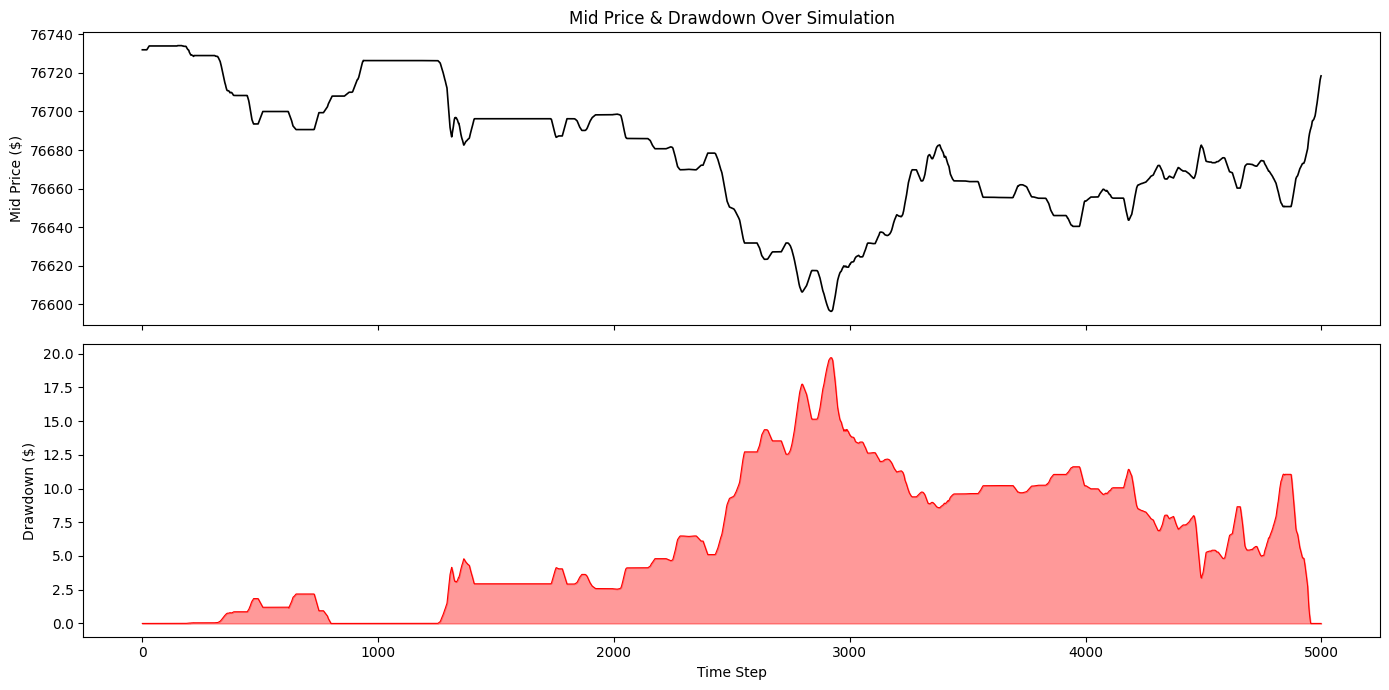

Max Drawdown: $0.0000


In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(results.index, results['Mid_Price'], color='black', linewidth=1.2)
ax1.set_ylabel('Mid Price ($)')
ax1.set_title('Mid Price & Drawdown Over Simulation')

ax2.fill_between(results.index, drawdown, 0, color='red', alpha=0.4)
ax2.plot(results.index, drawdown, color='red', linewidth=0.8)
ax2.set_ylabel('Drawdown ($)')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

print(f"Max Drawdown: ${drawdown.min():.4f}")

In [16]:
results.loc[results['Mid_Price'].idxmin()]

Mid_Price            76596.312000
Reservation_Price    76596.312000
Bid                  76594.663090
Ask                  76597.960910
Position                 0.229426
PnL                    -17.227822
Spread                   3.297821
Name: 2919, dtype: float64

In [17]:
skewness = returns.skew()
kurtosis = returns.kurtosis()
win_rate = (returns > 0).sum() / len(returns)
avg_win = returns[returns > 0].mean()
avg_loss = returns[returns < 0].mean()
profit_factor = abs(avg_win / avg_loss)

print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Win rate: {win_rate}")
print(f"Avg win: {avg_win}")
print(f"Avg loss: {avg_loss}")
print(f"Profit factor: {profit_factor}")

Skewness: 1.378296772001822
Kurtosis: 8.550498306260758
Win rate: 0.3682736547309462
Avg win: 0.035317290594966286
Avg loss: -0.025905243197894636
Profit factor: 1.3633259616661921


Regime Classifier

In [28]:
def analyze_regime():
    for regime in ['trending', 'mean_reverting']:
        mask = results['regime'] == regime
        regime_returns = results[mask]['PnL'].diff().dropna()
        regime_sharpe = regime_returns.mean() / regime_returns.std() * math.sqrt(5000)
        print(f"{regime}: Sharpe={regime_sharpe:.2f}, Periods={mask.sum()}")

Rolling Momentum

In [29]:
results['returns_rolling'] = results['Mid_Price'].pct_change().rolling(50).mean()
results['regime'] = results['returns_rolling'].apply(
    lambda x: 'trending' if abs(x) > 0.00005 else 'mean_reverting'
)

analyze_regime()

trending: Sharpe=nan, Periods=0
mean_reverting: Sharpe=2.93, Periods=5000


Price vs rolling average

In [30]:
rolling_mean = results['Mid_Price'].rolling(100).mean()
deviation = abs(results['Mid_Price'] - rolling_mean) / rolling_mean
threshold = deviation.quantile(0.75)

results['regime'] = (deviation > threshold).map({True: 'trending', False: 'mean_reverting'})
results['regime'] = results.apply(
    lambda row: 'trending' if abs(row['Mid_Price'] - rolling_mean[row.name]) > rolling_mean[row.name] * threshold else 'mean_reverting', axis=1
)

analyze_regime()

trending: Sharpe=2.45, Periods=1226
mean_reverting: Sharpe=-0.65, Periods=3774


The simulation data is predominantly mean-reverting, so we use a price vs. rolling average methodology to label the top 25% of deviations as trending periods for comparative analysis.

The strategy shows positive Sharpe in trending regimes, but analysis suggests this is partially attributable to inventory exposure rather than pure spread capture. The explanation for huge wins and losses in these simulations is that during a huge price move the strategy has positive or negative exposure. PnL skyrockets or plummets due to accidental directional trading. Holding a position during a trending regime results in large moves in PnL. It's luck rather than a comprehensive market making strategy. In mean-reverting regimes where spread capture should theoretically dominate, performance is negative, suggesting parameter calibration needs further work.

I definitely think that parameter tuning would help, since this was not a focus in earlier parts of the project. Functionality and minor tuning were more of a priority. I think getting a better estimate of sigma and gamma would be very beneficial. I think the reservation price model needs some tuning because it basically tracks the mid-price. It doesn't deviate very often from the mid-price, which defeats the purpose of having a reservation price. We can dynamically change the spread, but it's center (the reservation price) controls how the spread moves. Otherwise why not just create a spread around the mid-price if the reservation price behaves the same way.

- The inventory penalty is too small. 
- Sigma needs to be in dollar terms not percentage returns.
- Gamma needs to be larger to create meaningful inventory penalty.
- Kappa, OFI thresholds, and quote size are additional candidates for systematic optimization.

This leads to Bayesian Optimization.

Parameter Tuning

In [ ]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [ ]:
trades = get_btc_trades_extended()
print(f"Got {len(trades)} trades")

Got 5000 trades
trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-20 04:23:18.816857+00:00,1021369104,buy,4.000000e-08,76729.83
2026-05-20 04:23:19.344312+00:00,1021369105,sell,4.857000e-05,76729.88
2026-05-20 04:23:19.477619+00:00,1021369106,buy,4.000000e-08,76729.87
2026-05-20 04:23:19.783803+00:00,1021369107,buy,1.200000e-07,76729.87
2026-05-20 04:23:20.065305+00:00,1021369108,buy,5.000000e-08,76729.87


In [ ]:
import numpy as np

gammas = np.linspace(0.05, 0.5, 20)
kappas = np.linspace(0.05, 3.0, 20)
alphas = np.linspace(0.05, 3.0, 20)
betas = np.linspace(0.05, 3.0, 20)
ofi_thresholds = np.linspace(0.5, 0.9, 20)

In [ ]:
def run_simulation(gamma=0.1, kappa=1.5, alpha=1.0, beta=1.0, ofi_threshold=0.8, mid_price_window=20):
    book = OrderBook()
    mm = MarketMaker(order_book=book, gamma=gamma, kappa=kappa, alpha=alpha, beta=beta)
    sim = Simulator(mm, book, trades, mid_price_window)
    sim.run(ofi_threshold)
    sim_results = sim.get_results()
    returns = sim_results['PnL'].diff().dropna()
    return returns.mean() / returns.std()

In [ ]:
def plot_param(**kwargs):
    assert len(kwargs) == 1, "Pass exactly one parameter to sweep, e.g. plot_param(gamma=gammas)"
    param_name, param_list = next(iter(kwargs.items()))

    sharpes = [run_simulation(**{param_name: x}) for x in param_list]

    plt.figure(figsize=(10, 4))
    plt.plot(param_list, sharpes, marker='o', markersize=3)
    plt.xlabel(param_name)
    plt.ylabel('Sharpe Ratio')
    plt.title(f'Sharpe vs {param_name}')
    plt.tight_layout()
    plt.show()